# BANCO DE DADOS 2

## Exploração inicial 

Existe mercado e movimentação suficiente sobre bitcoins para se fazer a análise?

SELECT
  market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%bitcoin% %reach%'
ORDER BY volume DESC
LIMIT 30;

SELECT
  COUNT(*)                    AS n_mercados,
  ROUND(SUM(volume) / 1e6, 1) AS volume_total_musd,
  ROUND(AVG(volume), 0)       AS volume_medio_usd
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%bitcoin% %reach%';


[{
  "n_mercados": "1000",
  "volume_total_musd": "823.0",
  "volume_medio_usd": "823026.0"
}]

Temos uma quantidade de 1000 mercados que se adequam ao formato "Bitcoin reach [...]" e, nesses mercados, o volume ultrapassa o valor médio de 800.000USD, ou seja, esses mercados possuem movimentação que parece ser suficiente para uma análise.

## Exploração de mercados especificos para tentar encontrar algum padrão

In [41]:
#importando os módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [42]:

#Lendo os dados do primeiro mercado estudado (Will Bitcoin reach $1,000,000 by December 31, 2025?)
mercado1 = pd.read_csv("./dados/mercado_1.csv")
mercado1["trade_date"] = pd.to_datetime(mercado1["trade_date"])
mercado1

,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia
0,2024-12-30,18,19115.0,0.685,0.039,0.961,0.922
1,2024-12-31,77,8358.0,0.634,0.041,0.957,0.916
2,2025-01-01,23,2773.0,0.835,0.048,0.957,0.909
3,2025-01-02,82,4421.0,0.589,0.043,0.958,0.915
4,2025-01-03,111,11567.0,0.536,0.040,0.959,0.919
...,...,...,...,...,...,...,...
363,2025-12-28,121,35517.0,0.240,0.001,0.999,0.998
364,2025-12-29,1663,640948.0,0.348,0.001,0.999,0.998
365,2025-12-30,73,144.0,0.001,0.001,0.001,0.000
366,2025-12-31,41,129.0,0.001,0.001,0.001,0.000


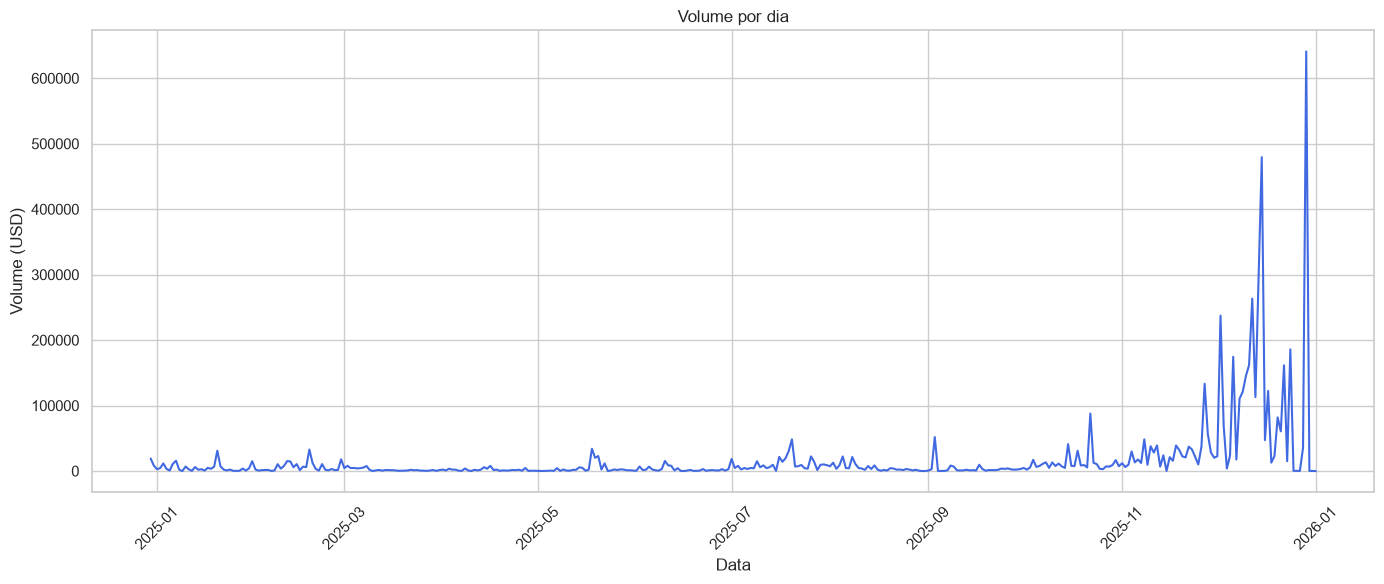

In [43]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado1,
    x="trade_date",
    y="volume_usd",
    color="royalblue"
)

plt.title("Volume por dia")
plt.xlabel("Data")
plt.ylabel("Volume (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

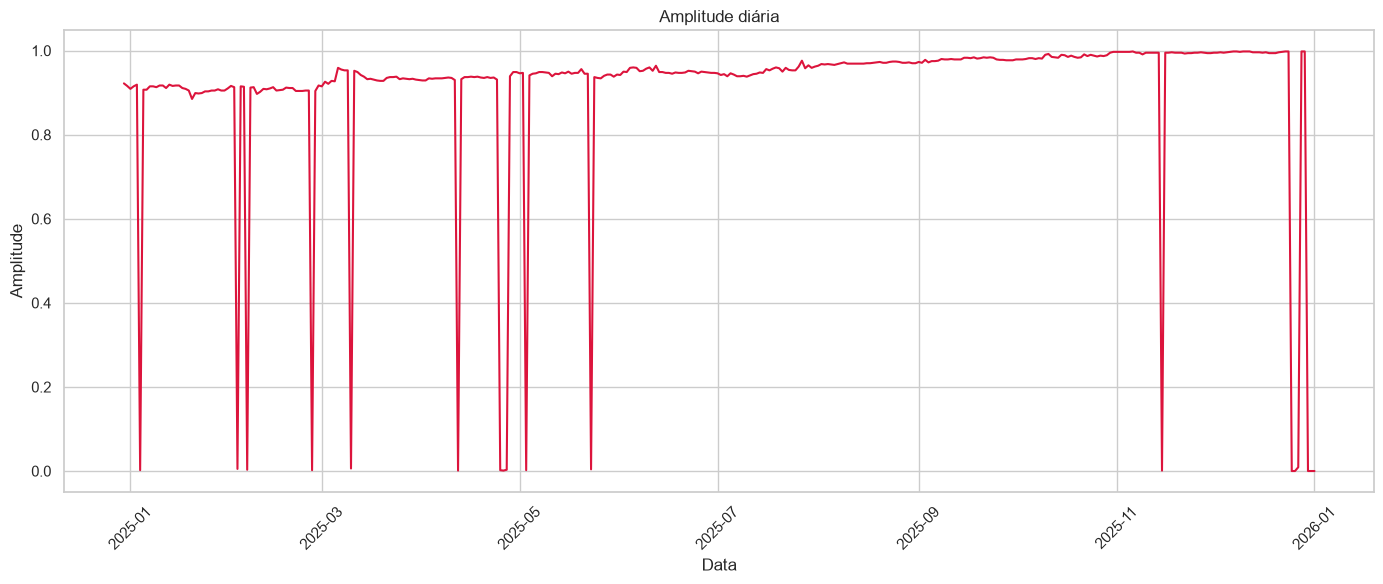

In [44]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado1,
    x="trade_date",
    y="amplitude_dia",
    color="crimson"
)

plt.title("Amplitude diária")
plt.xlabel("Data")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

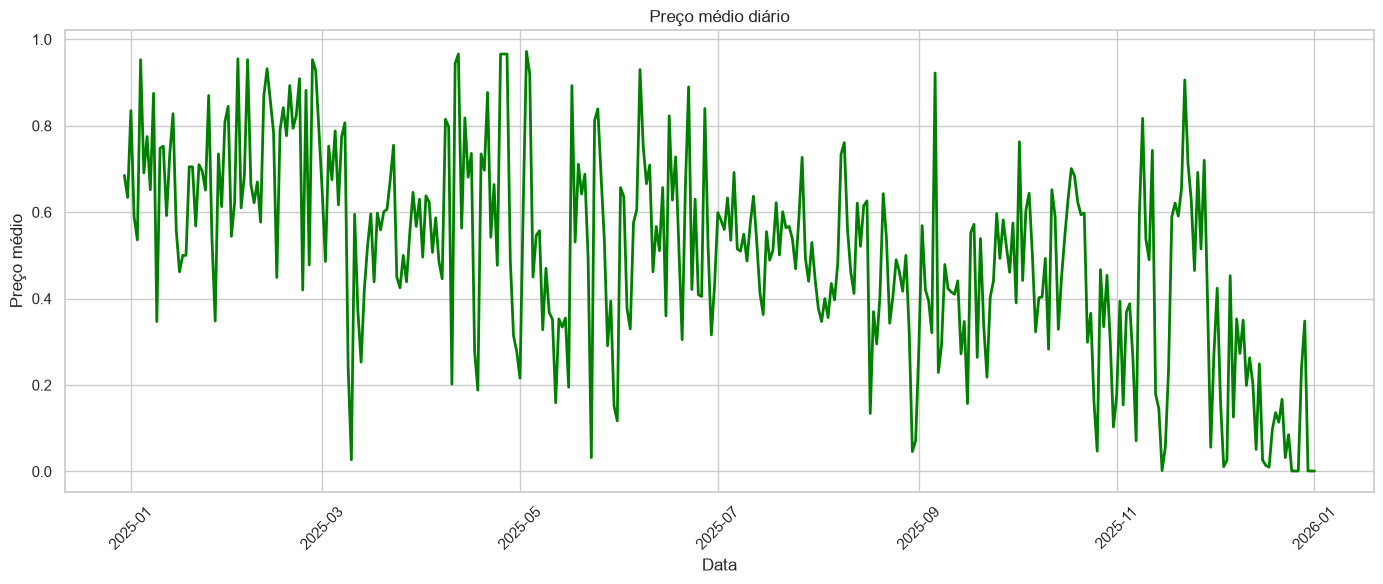

In [45]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado1,
    x="trade_date",
    y="preco_medio",
    color="green",
    linewidth=2
)

plt.title("Preço médio diário")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
mercado1[["preco_medio", "amplitude_dia", "volume_usd"]].corr()

,preco_medio,amplitude_dia,volume_usd
preco_medio,1.000000,-0.042182,-0.181951
amplitude_dia,-0.042182,1.000000,0.111498
volume_usd,-0.181951,0.111498,1.000000


In [47]:
#Lendo os dados do segundo mercado estudado (Will Bitcoin reach $150,000 in February?)
mercado2 = pd.read_csv("./dados/mercado_2.csv")
mercado2["trade_date"] = pd.to_datetime(mercado2["trade_date"])
mercado2

,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia
0,2026-01-31,68,7901.0,0.369,0.004,0.991,0.987
1,2026-02-01,530,77559.0,0.320,0.002,0.997,0.995
2,2026-02-02,1570,89560.0,0.144,0.004,0.996,0.992
3,2026-02-03,2561,63610.0,0.085,0.004,0.996,0.992
4,2026-02-04,1296,71109.0,0.108,0.003,0.996,0.993
5,2026-02-05,1335,119006.0,0.325,0.003,0.996,0.993
6,2026-02-06,975,6573.0,0.004,0.003,0.997,0.994
7,2026-02-07,1012,66860.0,0.109,0.003,0.996,0.993
8,2026-02-08,708,11710.0,0.056,0.003,0.997,0.994
9,2026-02-09,1564,376464.0,0.254,0.002,0.998,0.996


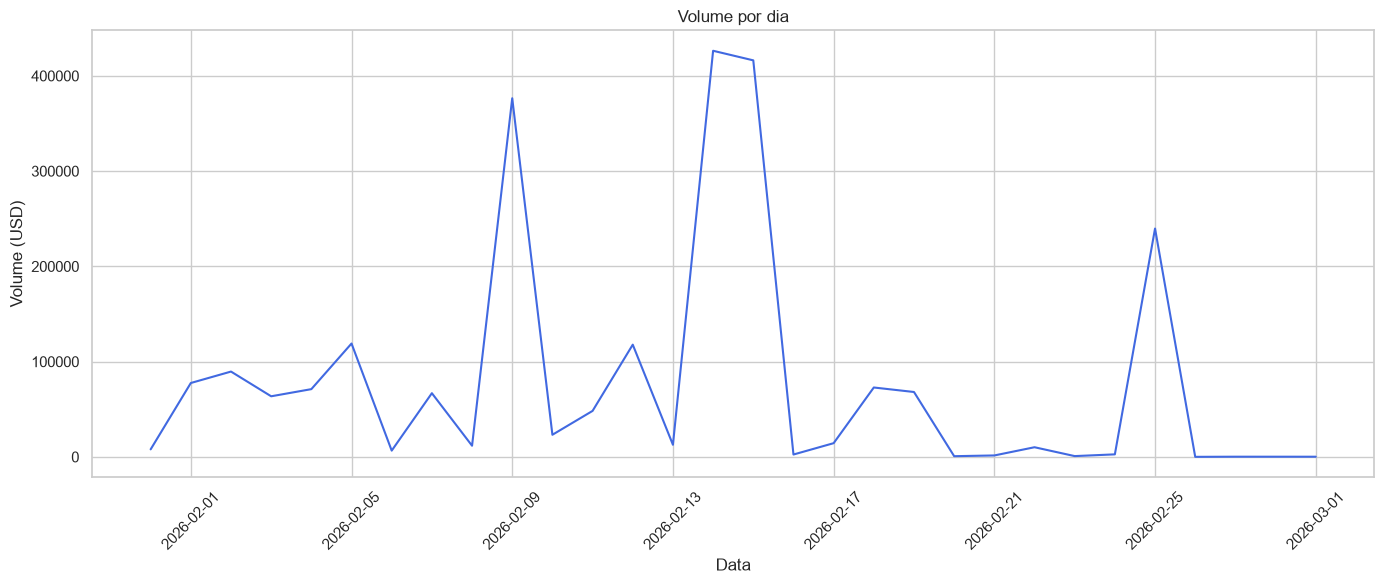

In [48]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado2,
    x="trade_date",
    y="volume_usd",
    color="royalblue"
)

plt.title("Volume por dia")
plt.xlabel("Data")
plt.ylabel("Volume (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

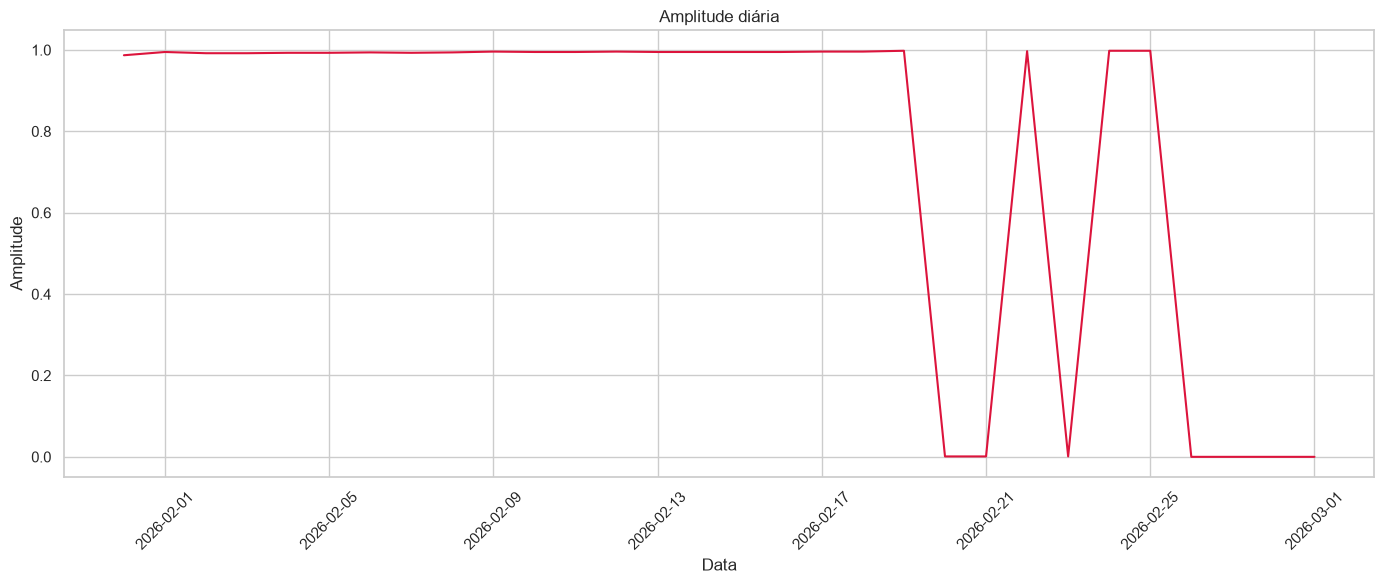

In [49]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado2,
    x="trade_date",
    y="amplitude_dia",
    color="crimson"
)

plt.title("Amplitude diária")
plt.xlabel("Data")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

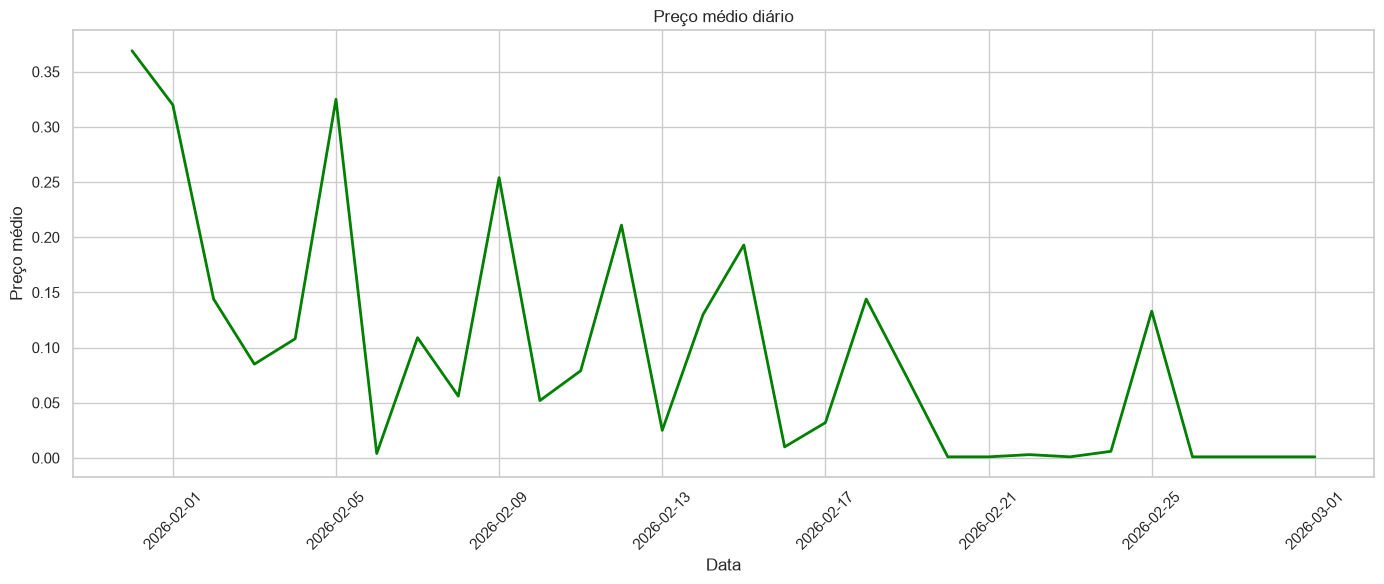

In [50]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado2,
    x="trade_date",
    y="preco_medio",
    color="green",
    linewidth=2
)

plt.title("Preço médio diário")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
mercado2[["preco_medio", "amplitude_dia", "volume_usd"]].corr()

,preco_medio,amplitude_dia,volume_usd
preco_medio,1.000000,0.487820,0.477354
amplitude_dia,0.487820,1.000000,0.355278
volume_usd,0.477354,0.355278,1.000000


A partir dessas explorações, notamos que o comportamento de um mercado sobre o periodo de um ano parece se comportar diferentemente de um mercado com um periodo menor. Assim,  

In [52]:
#Lendo os dados do terceiro mercado estudado (Will Bitcoin reach $150,000 in March?)
mercado3 = pd.read_csv("./dados/mercado_3.csv")
mercado3["trade_date"] = pd.to_datetime(mercado3["trade_date"])
mercado2

,trade_date,daily_trade_count,volume_usd,preco_medio,preco_min,preco_max,amplitude_dia
0,2026-01-31,68,7901.0,0.369,0.004,0.991,0.987
1,2026-02-01,530,77559.0,0.320,0.002,0.997,0.995
2,2026-02-02,1570,89560.0,0.144,0.004,0.996,0.992
3,2026-02-03,2561,63610.0,0.085,0.004,0.996,0.992
4,2026-02-04,1296,71109.0,0.108,0.003,0.996,0.993
5,2026-02-05,1335,119006.0,0.325,0.003,0.996,0.993
6,2026-02-06,975,6573.0,0.004,0.003,0.997,0.994
7,2026-02-07,1012,66860.0,0.109,0.003,0.996,0.993
8,2026-02-08,708,11710.0,0.056,0.003,0.997,0.994
9,2026-02-09,1564,376464.0,0.254,0.002,0.998,0.996


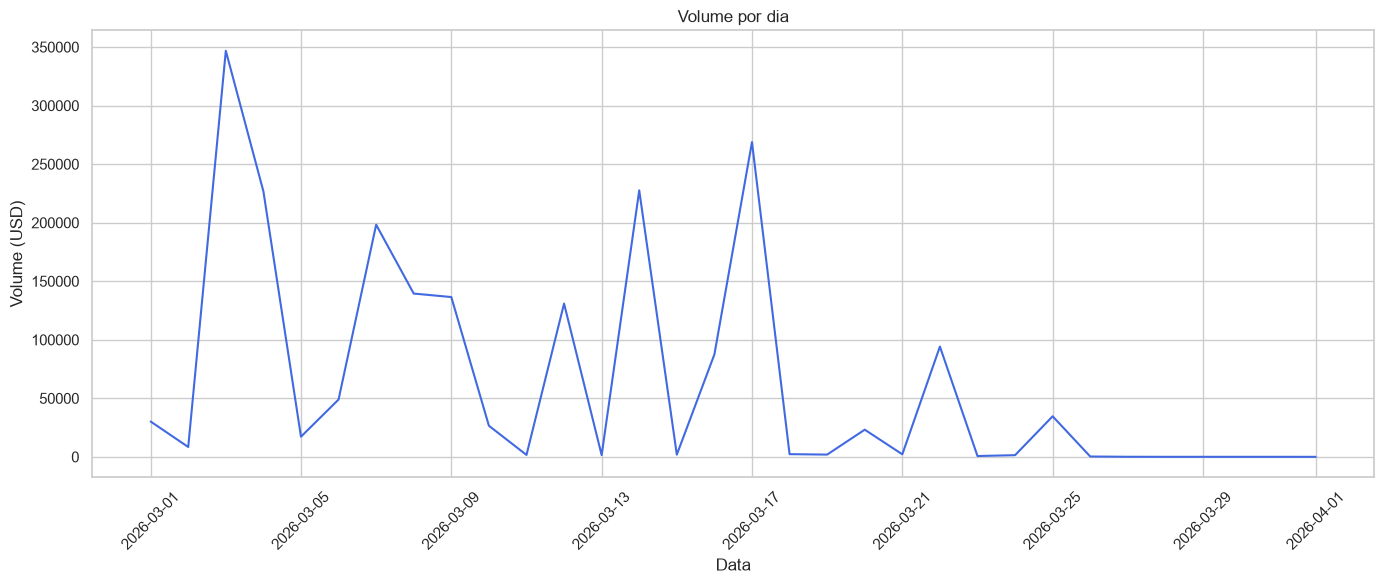

In [53]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado3,
    x="trade_date",
    y="volume_usd",
    color="royalblue"
)

plt.title("Volume por dia")
plt.xlabel("Data")
plt.ylabel("Volume (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

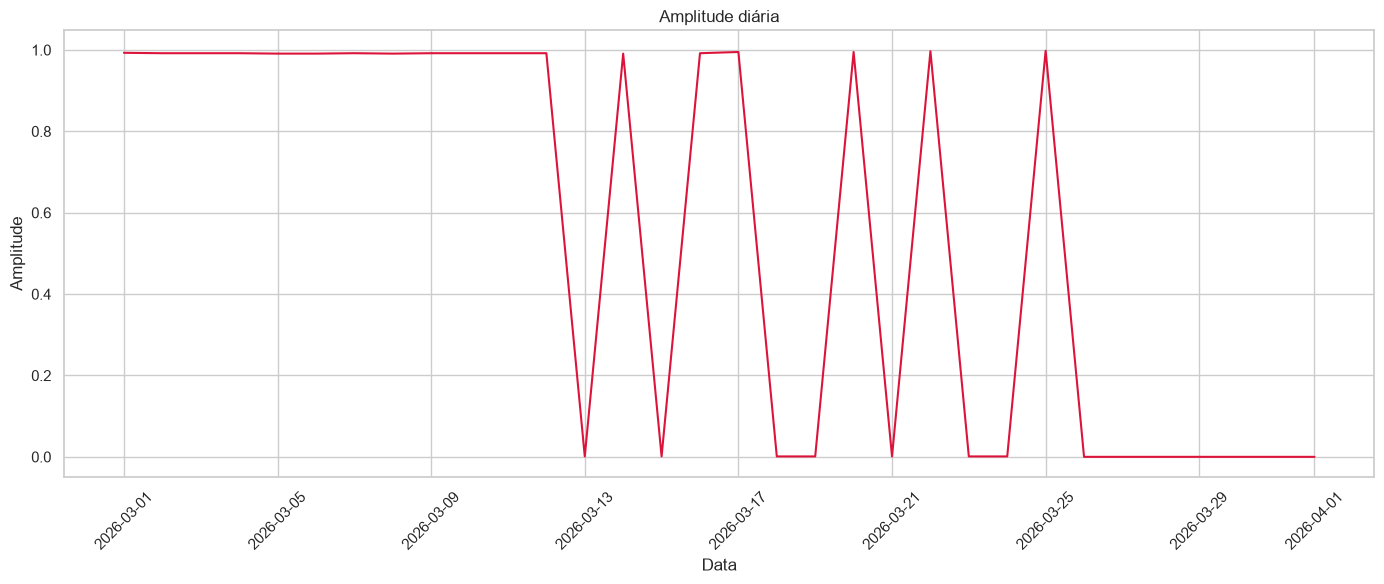

In [54]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado3,
    x="trade_date",
    y="amplitude_dia",
    color="crimson"
)

plt.title("Amplitude diária")
plt.xlabel("Data")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

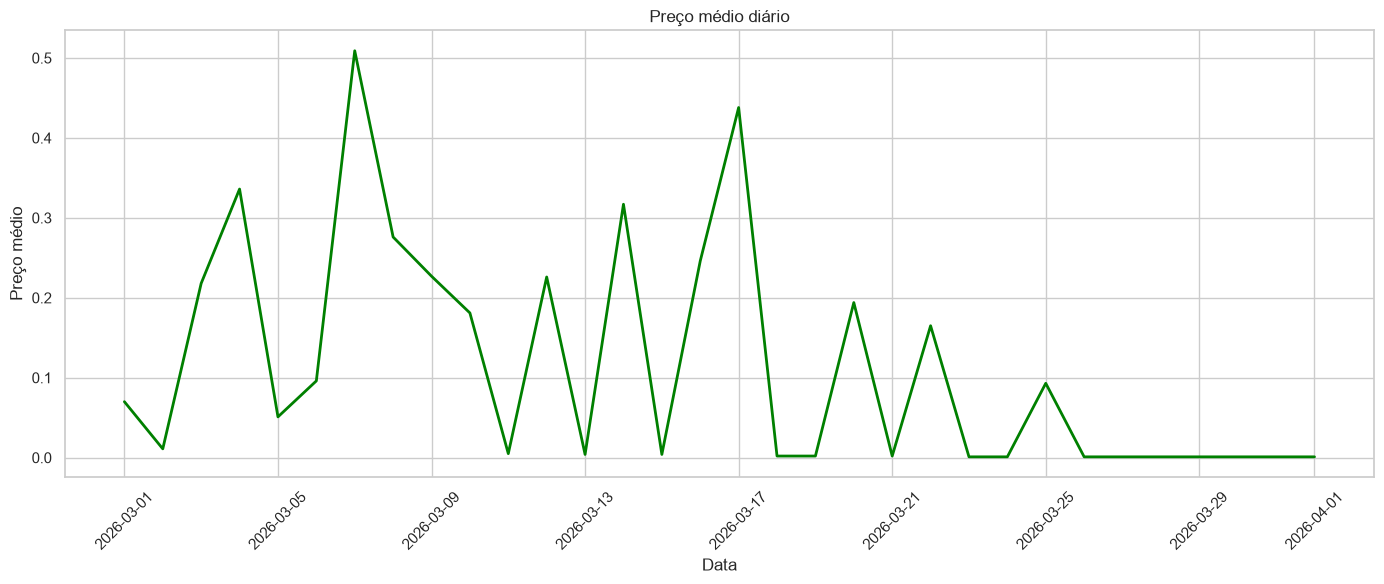

In [55]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14,6))

sns.lineplot(
    data=mercado3,
    x="trade_date",
    y="preco_medio",
    color="green",
    linewidth=2
)

plt.title("Preço médio diário")
plt.xlabel("Data")
plt.ylabel("Preço médio")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [56]:
mercado3[["preco_medio", "amplitude_dia", "volume_usd"]].corr()

,preco_medio,amplitude_dia,volume_usd
preco_medio,1.000000,0.701372,0.847707
amplitude_dia,0.701372,1.000000,0.597929
volume_usd,0.847707,0.597929,1.000000


Notamos que para intervalos menores, o comportamento parece ser mais parecido (mesmo comparando meses diferentes) e que parece haver correlação entre o preco_medio, amplitude e volume. 

## Mercados de menos de 1 mês com 'march'

WITH top_markets AS (
  SELECT
    market_id,
    question,
    created_at,
    end_date,
    volume
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE
    LOWER(question) LIKE '%bitcoin% %reach% %march 31%'
    AND DATE(end_date) < DATE_ADD(DATE(created_at), INTERVAL 1 MONTH)
  ORDER BY volume DESC
  LIMIT 30
)

SELECT
  tm.market_id,
  tm.question,
  TIMESTAMP_TRUNC(t.trade_timestamp, HOUR) AS hora,
  COUNT(*) AS trades,
  ROUND(SUM(t.usd_amount), 0) AS volume_usd,
  ROUND(AVG(t.price), 3) AS preco_medio,
  ROUND(MIN(t.price), 3) AS preco_min,
  ROUND(MAX(t.price), 3) AS preco_max
FROM top_markets tm
JOIN `even-continuity-441808-j0.polymarket_optimized.trades` t
  ON tm.market_id = t.market_id
WHERE
  t.trade_timestamp >= TIMESTAMP('2026-01-01')
  AND t.trade_timestamp BETWEEN tm.created_at AND tm.end_date
GROUP BY
  tm.market_id,
  tm.question,
  hora
ORDER BY
  tm.market_id,
  hora;

In [68]:
mercadoAteMar = pd.read_csv("./dados/mercados_ate_marco.csv")
mercadoAteMar["hora"] = pd.to_datetime(mercadoAteMar["hora"])

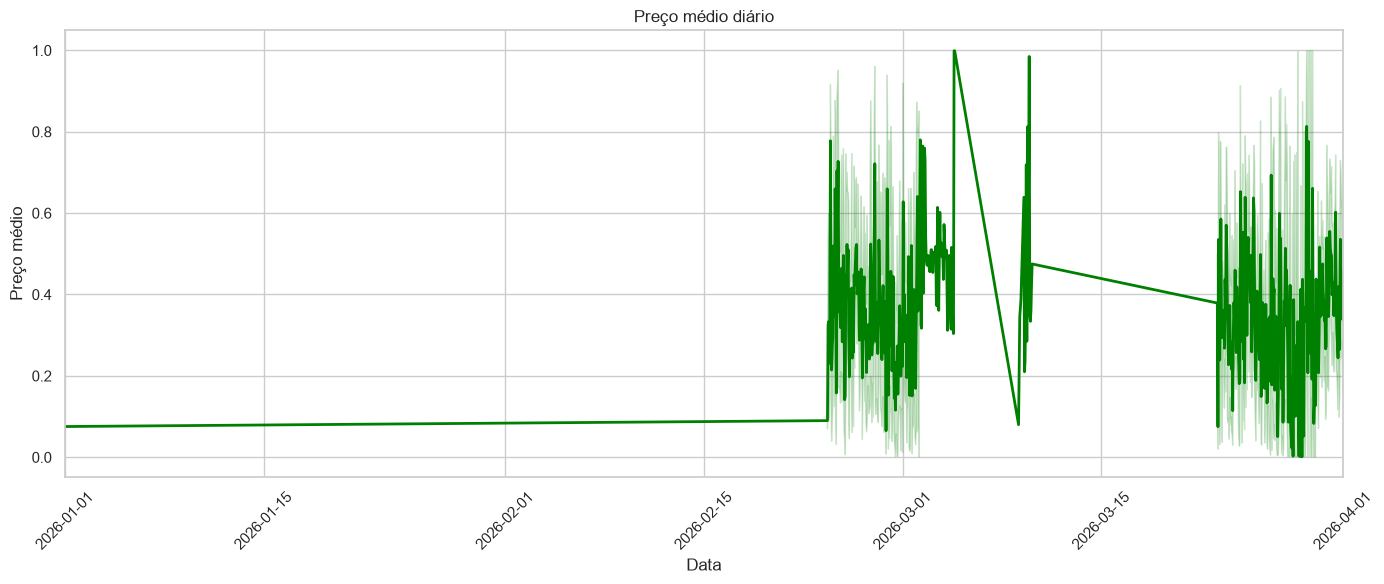

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14,6))

sns.lineplot(
    data=mercadoAteMar,
    x="hora",
    y="preco_medio",
    color="green",
    linewidth=2,
    ax=ax
)

ax.set_title("Preço médio diário")
ax.set_xlabel("Data")
ax.set_ylabel("Preço médio")
ax.tick_params(axis="x", rotation=45)

ax.set_xlim(datetime(2026, 1, 1), datetime(2026, 4, 1))

plt.tight_layout()
plt.show()

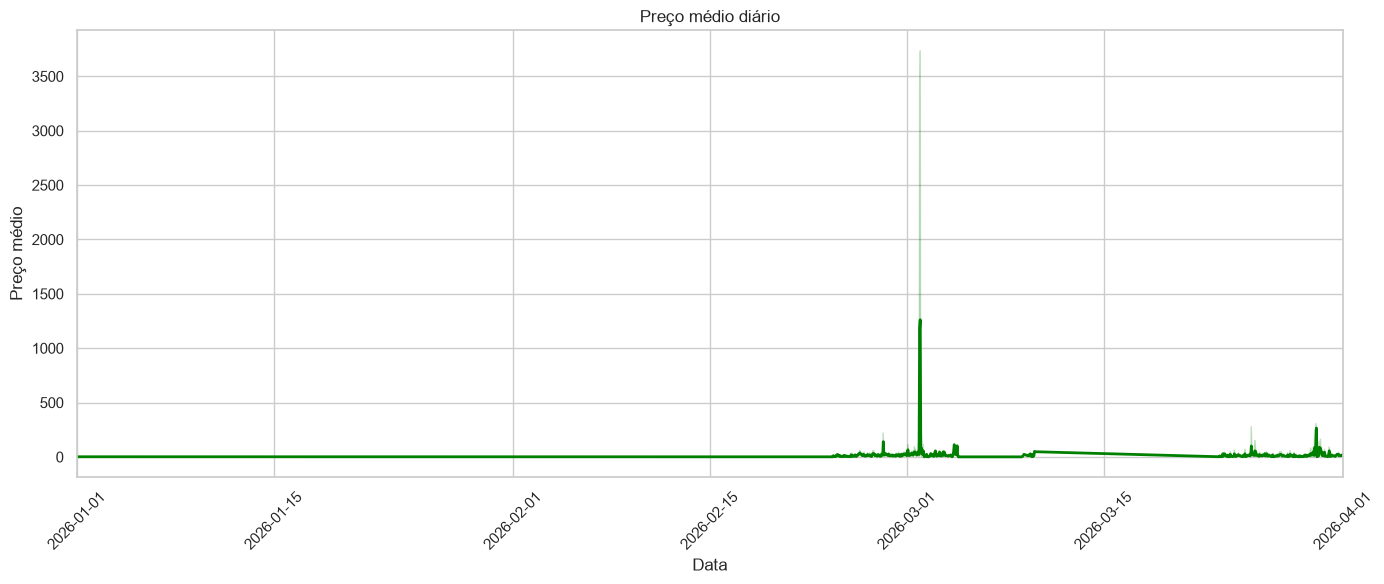

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14,6))

sns.lineplot(
    data=mercadoAteMar,
    x="hora",
    y="trades",
    color="green",
    linewidth=2,
    ax=ax
)

ax.set_title("Trades por data")
ax.set_xlabel("Data")
ax.set_ylabel("Trades")
ax.tick_params(axis="x", rotation=45)

ax.set_xlim(datetime(2026, 1, 1), datetime(2026, 4, 1))

plt.tight_layout()
plt.show()

Analisando esses gráficos, notamos que há vários períodos em que há poucas ou quase nenhuma trades com breves momentos de disparo. Assim, alertas que avisam quando são esses momentos de disparo, podem fazer sentido.

## Alertas
### Trades acima do normal
WITH top_markets AS (
  SELECT
    market_id,
    question,
    created_at,
    end_date,
    volume
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE
    LOWER(question) LIKE '%bitcoin%'
    AND LOWER(question) LIKE '%reach%'
    AND LOWER(question) LIKE '%march 31%'
    AND DATE(end_date) < DATE_ADD(DATE(created_at), INTERVAL 1 MONTH)
  ORDER BY volume DESC
  LIMIT 30
),

daily_trades AS (
  SELECT
    tm.market_id,
    tm.question,
    DATE(t.trade_timestamp) AS dia,
    COUNT(*) AS trades,
    SUM(t.usd_amount) AS volume_usd
  FROM top_markets tm
  JOIN `even-continuity-441808-j0.polymarket_optimized.trades` t
    ON tm.market_id = t.market_id
  WHERE
    t.trade_timestamp >= TIMESTAMP('2026-01-01')
    AND t.trade_timestamp BETWEEN tm.created_at AND tm.end_date
  GROUP BY
    tm.market_id,
    tm.question,
    dia
),

stats AS (
  SELECT
    AVG(trades) AS media_trades,
    STDDEV(trades) AS desvio_trades
  FROM daily_trades
)

SELECT
  d.*,
  s.media_trades,
  s.desvio_trades,
  d.trades - s.media_trades AS excesso_trades
FROM daily_trades d
CROSS JOIN stats s
WHERE
  d.trades > s.media_trades + 2 * s.desvio_trades
ORDER BY
  d.trades DESC;

### Alerta Preco Médio acima do Comum
WITH top_markets AS (
  SELECT
    market_id,
    question,
    created_at,
    end_date,
    volume
  FROM `even-continuity-441808-j0.polymarket_optimized.markets`
  WHERE
    LOWER(question) LIKE '%bitcoin%'
    AND LOWER(question) LIKE '%reach%'
    AND LOWER(question) LIKE '%march 31%'
    AND DATE(end_date) < DATE_ADD(DATE(created_at), INTERVAL 1 MONTH)
  ORDER BY volume DESC
  LIMIT 30
),

daily_price AS (
  SELECT
    tm.market_id,
    tm.question,
    DATE(t.trade_timestamp) AS dia,
    AVG(t.price) AS preco_medio
  FROM top_markets tm
  JOIN `even-continuity-441808-j0.polymarket_optimized.trades` t
    ON tm.market_id = t.market_id
  WHERE
    t.trade_timestamp >= TIMESTAMP('2026-01-01')
    AND t.trade_timestamp BETWEEN tm.created_at AND tm.end_date
  GROUP BY
    tm.market_id,
    tm.question,
    dia
),

stats AS (
  SELECT
    AVG(preco_medio) AS media_preco,
    STDDEV(preco_medio) AS desvio_preco
  FROM daily_price
)

SELECT
  d.*,
  s.media_preco,
  s.desvio_preco,
  d.preco_medio - s.media_preco AS distancia_media
FROM daily_price d
CROSS JOIN stats s
WHERE
  ABS(d.preco_medio - s.media_preco) > s.desvio_preco
ORDER BY
  ABS(d.preco_medio - s.media_preco) DESC;